# Trabajo práctico 1: Método de Euler

### Grupo 3
### Gonzalo Díaz Excoffon y Boris Sebastián Rubinstein

---

Dada la siguiente ecuación diferencial ordinaria con su condición inicial:
$$
\begin{cases} 
y' = x^{\frac{3+n}{n}} y, \\
y(0) = 1, 
\end{cases}

\qquad x \in \Omega \quad , \quad \Omega = [0,2] \in \mathbb{R} $$

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return (x**2) * y


---

**Ejercicio 1**
Resolver el problema de manera exacta.

***Resolucion***
Es una ecuación donde se pueden separar las variables, despejando todo lo que depende de $x$ del lado derecho y todo lo que depende de $y$ del lado del izquierdo, integramos, obteniendo lo siguiente:

$$ \ln{ \left\lvert y \right\rvert } = \frac{x^{\frac{3+2n}{n}}}{\frac{3+2n}{n}} + C \qquad$$

Despejando y reutilizando la constante C para la constante K donde $ K = e ^ C$, llegamos a:

$$ y(x) = K e^{\frac{n}{3+ 2n} x^{\frac{3+2n}{n}}}$$

Usando el valor inicial llegamos a que $K = 1$ por lo que la solución de este PVI es, siendo el grupo n = 3:

$$ y(x) = e^{\frac{1}{3} x^3}$$


---

**Ejercicio 2.** Usando valores de $h_1 = 0.2$, $h_2 = 0.1$, $h_3 = 0.01$ construya tres aproximaciones numéricas de la solución mediante el método de Euler y tres aproximaciones utilizando el método de Heun.


***Resolución***
Primero vamos a discretizar el intervalo $[0,2]$ en $ N + 1 $ puntos discretos. De esta forma tenemos que el primer punto discreto le corresponde al $x = 0$ y el último al $x = 2$, con $ N $ puntos internos entre ambos extremos e iniciando el índice en 0 para utilizar la misma convención de índices que el lenguaje en el que implementamos los métodos numéricos, Python. O sea para $ i = 0$, siendo $i$ el iterador de índices, tenemos el primer punto discreto $x = 0$. En la consigna se piden 3 tamaños de pasos distintos, por lo que se debe discretizar el intervalo de 3 maneras distintas. Siendo $h$ el paso, cada paso resulta ser de $ h = \frac{2}{N}$, observandose en la Tabla 1 cada discretización con los valores resultantes.

$$
\begin{array}{|c|c|c|c|}
\hline
\text{Número de discretización} & \text{Paso } (h) & \text{Cantidad de puntos discretos} \\
\hline
1 & 0.2 & 10  \\
\hline
2 & 0.1 & 20 \\
\hline
3 & 0.01 & 200 \\
\hline
\end{array}
$$
<div align="center"><em>Tabla 1: Valores para la discretización del intervalo.</em></div>


In [37]:
# h es el tamaño del paso
h1 = 0.2
h2 = 0.1
h3 = 0.01

# N + 1 es el número de puntos discretos
N1 = int(2 / h1)
N2 = int(2 / h2)
N3 = int(2 / h3)

# Los distintos pasos generan distintas discretizaciones del intervalo [0, 2]
x1 = np.linspace(0, 2, N1+1)
x2 = np.linspace(0, 2, N2+1)
x3 = np.linspace(0, 2, N3+1)


Una vez discretizado el intervalo, se van a usar las siguientes ecuaciones para el método de **Euler** y el método de **Heun**, Ecuación (1) y Ecuación (2) respectivamente:

$$ y_{i + 1} = y_i + h f(x_i,y_i) \qquad (1)$$

$$ y_{i + 1} = y_i + \frac{h}{2} \left[ f(x_i, y_i) + f(x_{i+1}, y_{i+i}) \right] \qquad (2)$$

El método de Heun es un método implícito, para nuestra suerte, la función a analizar nos permite despejar el valor de $y_{i+1}$ en función de $x_i$, $x_{i+1}$, $y_i$ y $h$, obteniendo la siguiente expresión la cual será implementada en este trabajo:

$$ y_{i+1} = y_i \left[ \frac{1+\frac{h}{2}x_i^2}{1-\frac{h}{2}x_{i+1}^2} \right] $$


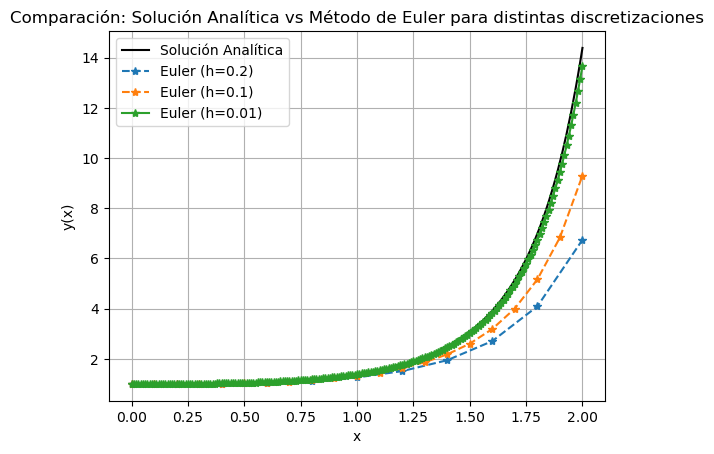

In [38]:
# Creamos los arreglos para almacenar los valores de y en cada paso
y1_E = np.zeros(N1+1)
y2_E = np.zeros(N2+1) 
y3_E = np.zeros(N3+1)

# Imponemos la condición inicial y(0) = 1
y1_E[0] = 1
y2_E[0] = 1
y3_E[0] = 1

# Aplicamos el método de Euler para cada discretización
for i in range(N1):
    y1_E[i + 1] = y1_E[i] + h1 * f(x1[i], y1_E[i])

for i in range(N2):
    y2_E[i + 1] = y2_E[i] + h2 * f(x2[i], y2_E[i])

for i in range(N3):
    y3_E[i + 1] = y3_E[i] + h3 * f(x3[i], y3_E[i])

# Graficamos la solución exacta con las aproximaciones obtenidas con el método de Euler
y_exacta = np.exp((x3**3) / 3)

plt.figure()
plt.title('Comparación: Solución Analítica vs Método de Euler para distintas discretizaciones')
plt.plot(x3, y_exacta, 'k-', label='Solución Analítica')
plt.plot(x1, y1_E, '*--', label='Euler (h=0.2)')
plt.plot(x2, y2_E, '*--', label='Euler (h=0.1)')
plt.plot(x3, y3_E, '*-', label='Euler (h=0.01)')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.legend()
plt.grid(True)
plt.show()

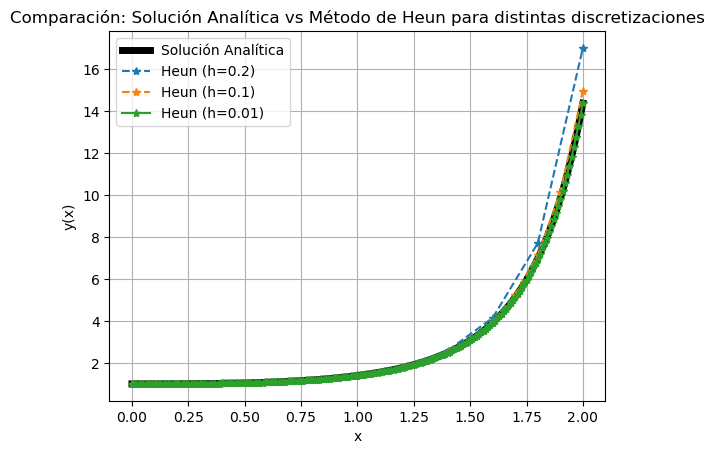

In [39]:
# Ahora, hacemos lo mismo para el método de Heun
y1_H1 = np.zeros(N1+1)
y2_H1 = np.zeros(N2+1) 
y3_H1 = np.zeros(N3+1)

# Imponemos la condición inicial y(0) = 1
y1_H1[0] = 1
y2_H1[0] = 1
y3_H1[0] = 1

# Aplicamos el método de Heun para cada discretización
for i in range(N1):
    y1_H1[i + 1] = y1_H1[i]*(1 + (h1 / 2) * (x1[i]**2))/(1 - (h1 / 2) * (x1[i+1]**2))
for i in range(N2):
    y2_H1[i + 1] = y2_H1[i]*(1 + (h2 / 2) * (x2[i]**2))/(1 - (h2 / 2) * (x2[i+1]**2))
for i in range(N3):
    y3_H1[i + 1] = y3_H1[i]*(1 + (h3 / 2) * (x3[i]**2))/(1 - (h3 / 2) * (x3[i+1]**2))

# Graficamos la solución exacta con las aproximaciones obtenidas con el método de Heun
plt.figure()
plt.title('Comparación: Solución Analítica vs Método de Heun para distintas discretizaciones')
plt.plot(x3, y_exacta, 'k-', linewidth = 5, label='Solución Analítica')
plt.plot(x1, y1_H1, '*--', label='Heun (h=0.2)')
plt.plot(x2, y2_H1, '*--', label='Heun (h=0.1)')
plt.plot(x3, y3_H1, '*-', label='Heun (h=0.01)')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.legend()
plt.grid(True)
plt.show()


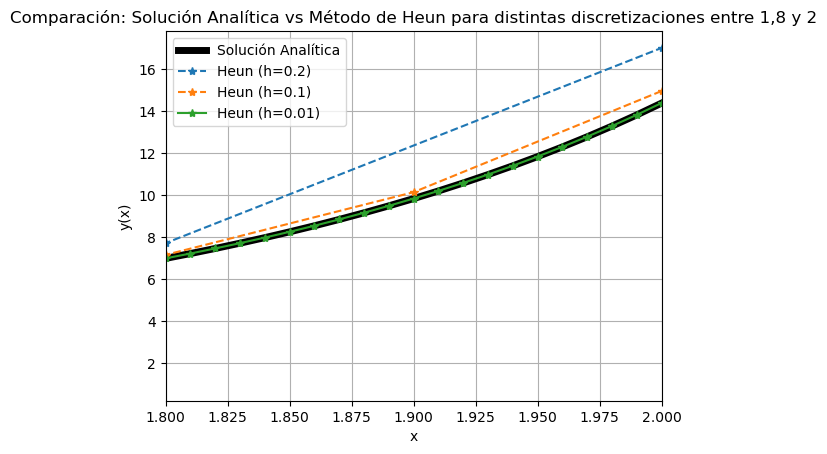

In [40]:
# Hacemos zoom entre 1,8 y 2 para que se observe mejor como difieren las distintas soluciones
plt.figure()
plt.title('Comparación: Solución Analítica vs Método de Heun para distintas discretizaciones entre 1,8 y 2')
plt.plot(x3, y_exacta, 'k-', linewidth = 5, label='Solución Analítica')
plt.plot(x1, y1_H1, '*--', label='Heun (h=0.2)')
plt.plot(x2, y2_H1, '*--', label='Heun (h=0.1)')
plt.plot(x3, y3_H1, '*-', label='Heun (h=0.01)')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.xlim(1.8, 2)
plt.legend()
plt.grid(True)
plt.show()

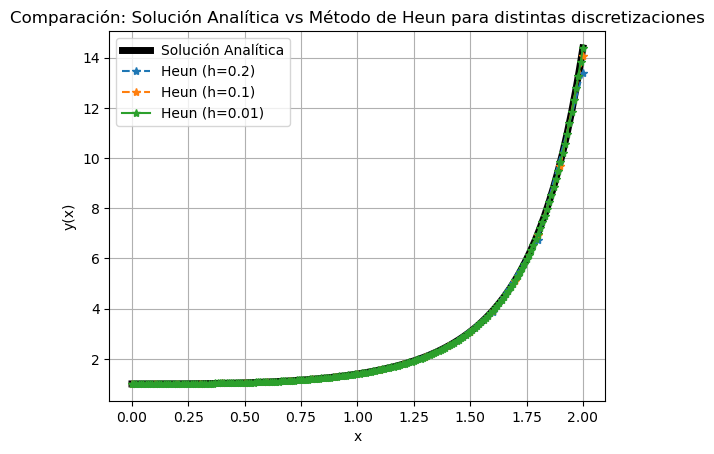

In [41]:
# Ahora, hacemos lo mismo para el método de Heun
y1_H2 = np.zeros(N1+1)
y2_H2 = np.zeros(N2+1) 
y3_H2 = np.zeros(N3+1)

# Imponemos la condición inicial y(0) = 1
y1_H2[0] = 1
y2_H2[0] = 1
y3_H2[0] = 1

# Aplicamos el método de Heun para cada discretización
for i in range(N1):
    y_star = y1_H2[i] + h1 * f(x1[i], y1_H2[i])
        
    y1_H2[i+1] = y1_H2[i] + (h1 / 2) * (f(x1[i], y1_H2[i]) + f(x1[i+1], y_star))


for i in range(N2):
    y_star = y2_H2[i] + h2 * f(x2[i], y2_H2[i])
        
    y2_H2[i+1] = y2_H2[i] + (h2 / 2) * (f(x2[i], y2_H2[i]) + f(x2[i+1], y_star))

for i in range(N3):
    y_star = y3_H2[i] + h3 * f(x3[i], y3_H2[i])
        
    y3_H2[i+1] = y3_H2[i] + (h3 / 2) * (f(x3[i], y3_H2[i]) + f(x3[i+1], y_star))

# Graficamos la solución exacta con las aproximaciones obtenidas con el método de Heun
plt.figure()
plt.title('Comparación: Solución Analítica vs Método de Heun para distintas discretizaciones')
plt.plot(x3, y_exacta, 'k-', linewidth = 5, label='Solución Analítica')
plt.plot(x1, y1_H2, '*--', label='Heun (h=0.2)')
plt.plot(x2, y2_H2, '*--', label='Heun (h=0.1)')
plt.plot(x3, y3_H2, '*-', label='Heun (h=0.01)')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.legend()
plt.grid(True)
plt.show()

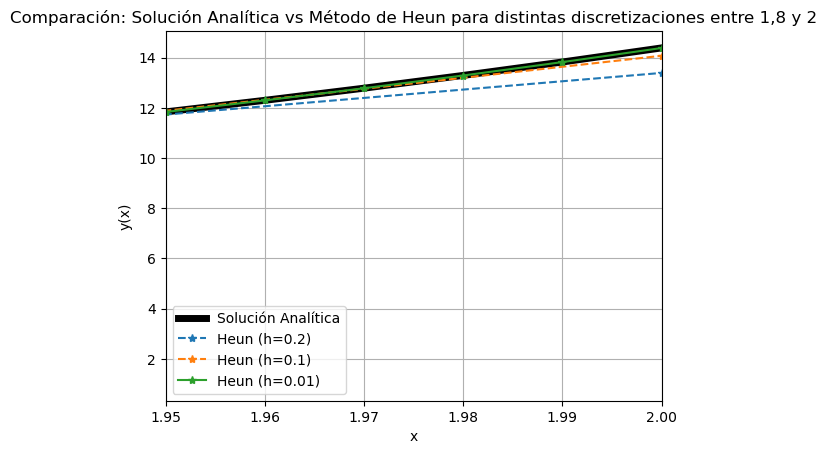

In [42]:
# Hacemos zoom entre 1,95 y 2 para que se observe mejor como difieren las distintas soluciones
plt.figure()
plt.title('Comparación: Solución Analítica vs Método de Heun para distintas discretizaciones entre 1,8 y 2')
plt.plot(x3, y_exacta, 'k-', linewidth = 5, label='Solución Analítica')
plt.plot(x1, y1_H2, '*--', label='Heun (h=0.2)')
plt.plot(x2, y2_H2, '*--', label='Heun (h=0.1)')
plt.plot(x3, y3_H2, '*-', label='Heun (h=0.01)')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.xlim(1.95, 2)
plt.legend()
plt.grid(True)
plt.show()


---


**Ejercicio 3.** Grafique dos campos de pendientes definidos por la función $f(x,y)$, en el primero de ellos grafique también la solución exacta obtenida analíticamente y las tres aproximaciones obtenidas mediante el método de Euler; en el segundo, grafique, además de la solución exacta, las tres aproximaciones obtenidas mediante el método de Heun.



---

**Ejercicio 4.** Estime el error global de ambos métodos para cada valor de $h$. Para ello, recuerde que para el método de Euler el *error de truncamiento local* en el paso $i$ está dado por

$$\tau := \frac{h^2}{2}y''(\mu) \quad \text{con} \quad \mu \in [x_0 + ih, x_0 + (i+1)h],$$

que para el método de Heun está dado por

$$\tau := \frac{h^3}{6}y'''(\mu) \quad \text{con} \quad \mu \in [x_0 + ih, x_0 + (i+1)h],$$

y que el *error global*, para ambos métodos, verifica la cota

$$|y(x_N) - y_h(x_N)| \le \frac{\tau_{\text{max}}}{Kh}(e^{K(x_N - x_0)} - 1)$$

donde $K$ es la constante de Lipschitz de $f(x,y)$ en la variable $y$ y $\tau_{\text{max}}$ es el máximo de los módulos de los errores de truncamiento local.

---

**Ejercicio 5.** Compare los errores globales para cada valor de $h$ con las diferencias (en módulo) entre $y(2)$ e $y_h(2)$ (obtenidas en el ítem 1 y 2 respectivamente).